In [96]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("ggplot")

### Load the data

In [97]:
# df = pd.read_csv('/Users/mahdisahil/Desktop/Predicting-LIfe-Expectancy/data/raw/Life Expectancy Data.csv')
df = pd.read_csv('/Users/mahdisahil/Dataset/Life Expectancy Data.csv')

In [98]:
df.shape

(2938, 22)

In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [100]:
df.columns.to_list()

['Country',
 'Year',
 'Status',
 'Life expectancy ',
 'Adult Mortality',
 'infant deaths',
 'Alcohol',
 'percentage expenditure',
 'Hepatitis B',
 'Measles ',
 ' BMI ',
 'under-five deaths ',
 'Polio',
 'Total expenditure',
 'Diphtheria ',
 ' HIV/AIDS',
 'GDP',
 'Population',
 ' thinness  1-19 years',
 ' thinness 5-9 years',
 'Income composition of resources',
 'Schooling']

In [101]:
print(df.columns.to_list())

df.columns = df.columns.str.strip()

print(df.columns.to_list())

['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', ' thinness 5-9 years', 'Income composition of resources', 'Schooling']
['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


# Standardizing column names

In [102]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("/", "_")
)

df.columns.to_list()

['country',
 'year',
 'status',
 'life_expectancy',
 'adult_mortality',
 'infant_deaths',
 'alcohol',
 'percentage_expenditure',
 'hepatitis_b',
 'measles',
 'bmi',
 'under_five_deaths',
 'polio',
 'total_expenditure',
 'diphtheria',
 'hiv_aids',
 'gdp',
 'population',
 'thinness_1_19_years',
 'thinness_5_9_years',
 'income_composition_of_resources',
 'schooling']

In [103]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          2938 non-null   str    
 1   year                             2938 non-null   int64  
 2   status                           2938 non-null   str    
 3   life_expectancy                  2928 non-null   float64
 4   adult_mortality                  2928 non-null   float64
 5   infant_deaths                    2938 non-null   int64  
 6   alcohol                          2744 non-null   float64
 7   percentage_expenditure           2938 non-null   float64
 8   hepatitis_b                      2385 non-null   float64
 9   measles                          2938 non-null   int64  
 10  bmi                              2904 non-null   float64
 11  under_five_deaths                2938 non-null   int64  
 12  polio                          

In [104]:
df.head()

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness_1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [105]:
df.isnull().sum().sort_values(ascending=False)

population                         652
hepatitis_b                        553
gdp                                448
total_expenditure                  226
alcohol                            194
income_composition_of_resources    167
schooling                          163
thinness_5_9_years                  34
thinness_1_19_years                 34
bmi                                 34
polio                               19
diphtheria                          19
life_expectancy                     10
adult_mortality                     10
hiv_aids                             0
country                              0
year                                 0
measles                              0
percentage_expenditure               0
infant_deaths                        0
status                               0
under_five_deaths                    0
dtype: int64

In [106]:
df.isnull().sum().sort_values(ascending=False)/ df.shape[0] * 100

population                         22.191967
hepatitis_b                        18.822328
gdp                                15.248468
total_expenditure                   7.692308
alcohol                             6.603131
income_composition_of_resources     5.684139
schooling                           5.547992
thinness_5_9_years                  1.157250
thinness_1_19_years                 1.157250
bmi                                 1.157250
polio                               0.646698
diphtheria                          0.646698
life_expectancy                     0.340368
adult_mortality                     0.340368
hiv_aids                            0.000000
country                             0.000000
year                                0.000000
measles                             0.000000
percentage_expenditure              0.000000
infant_deaths                       0.000000
status                              0.000000
under_five_deaths                   0.000000
dtype: flo

In [107]:
df.describe()

,year,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under_five_deaths,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness_1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [108]:
df.duplicated().sum()

np.int64(0)

In [109]:
for i in df.select_dtypes(include=["str"]).columns:
    print(df[i].value_counts())
    print("***" * 10)

country
Afghanistan              16
Albania                  16
Algeria                  16
Angola                   16
Antigua and Barbuda      16
                         ..
Niue                      1
Palau                     1
Saint Kitts and Nevis     1
San Marino                1
Tuvalu                    1
Name: count, Length: 193, dtype: int64
******************************
status
Developing    2426
Developed      512
Name: count, dtype: int64
******************************


# EDA

In [110]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,2938.0,2.007519e+03,4.613841e+00,2000.00000,2004.000000,2.008000e+03,2.012000e+03,2.015000e+03
life_expectancy,2928.0,6.922493e+01,9.523867e+00,36.30000,63.100000,7.210000e+01,7.570000e+01,8.900000e+01
adult_mortality,2928.0,1.647964e+02,1.242921e+02,1.00000,74.000000,1.440000e+02,2.280000e+02,7.230000e+02
infant_deaths,2938.0,3.030395e+01,1.179265e+02,0.00000,0.000000,3.000000e+00,2.200000e+01,1.800000e+03
alcohol,2744.0,4.602861e+00,4.052413e+00,0.01000,0.877500,3.755000e+00,7.702500e+00,1.787000e+01
percentage_expenditure,2938.0,7.382513e+02,1.987915e+03,0.00000,4.685343,6.491291e+01,4.415341e+02,1.947991e+04
hepatitis_b,2385.0,8.094046e+01,2.507002e+01,1.00000,77.000000,9.200000e+01,9.700000e+01,9.900000e+01
measles,2938.0,2.419592e+03,1.146727e+04,0.00000,0.000000,1.700000e+01,3.602500e+02,2.121830e+05
bmi,2904.0,3.832125e+01,2.004403e+01,1.00000,19.300000,4.350000e+01,5.620000e+01,8.730000e+01
under_five_deaths,2938.0,4.203574e+01,1.604455e+02,0.00000,0.000000,4.000000e+00,2.800000e+01,2.500000e+03


In [111]:
df.describe(include=["str"]).T

,count,unique,top,freq
country,2938,193,Afghanistan,16
status,2938,2,Developing,2426


# Target Variable Analysis

In [112]:
target = "life_expectancy"
df[target].describe()

count    2928.000000
mean       69.224932
std         9.523867
min        36.300000
25%        63.100000
50%        72.100000
75%        75.700000
max        89.000000
Name: life_expectancy, dtype: float64

In [113]:
df[target].isnull().sum()

np.int64(10)

In [114]:
df[target].skew()

np.float64(-0.6386047358773552)

The target variable `life_expectancy` has a skewness of -0.6386, indicating a moderate negative skew. This suggests that most observations are concentrated at relatively higher life expectancy values, with a smaller number of lower values extending the left tail of the distribution.

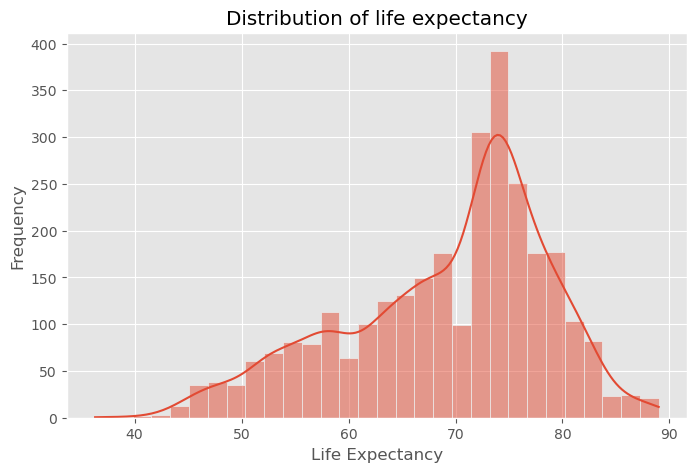

In [115]:
plt.figure(figsize=(8,5))
sns.histplot(data = df[target], kde=True)
plt.title("Distribution of life expectancy")
plt.xlabel("Life Expectancy")
plt.ylabel("Frequency")
plt.show()

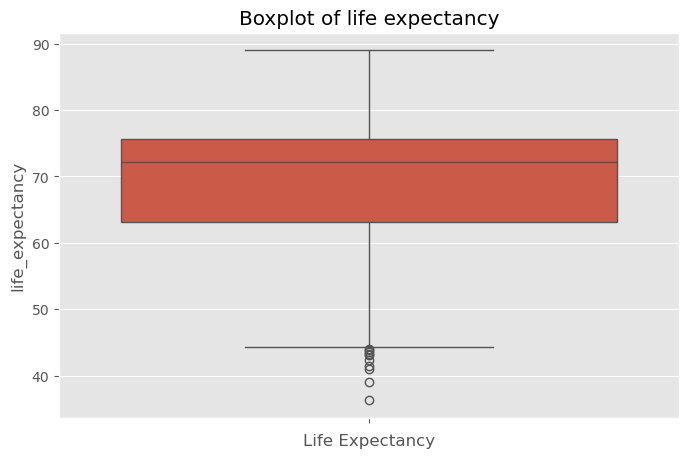

In [116]:
plt.figure(figsize=(8,5))
sns.boxplot(data = df[target])
plt.title("Boxplot of life expectancy")
plt.xlabel("Life Expectancy")
plt.show()

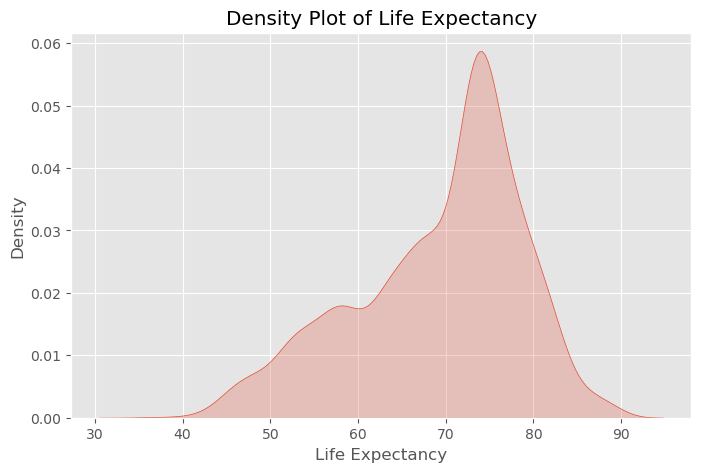

In [117]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df[target], fill=True)
plt.title("Density Plot of Life Expectancy")
plt.xlabel("Life Expectancy")
plt.show()

### Target Variable Analysis: `life_expectancy`

- The target variable has some missing values.
- Its skewness is `-0.6386`, which indicates a moderate negative skew.
- The distribution suggests that most observations are concentrated at relatively higher life expectancy values, with some lower values extending the left tail.
- The boxplot shows some outliers, but they appear to be logically plausible rather than obvious data errors.
- At this stage, the outliers should be retained and only documented.

# Numerical Feautures Analysis

In [118]:
numerical_features = df.select_dtypes(include=["number"]).columns
numerical_features = numerical_features.drop(target)

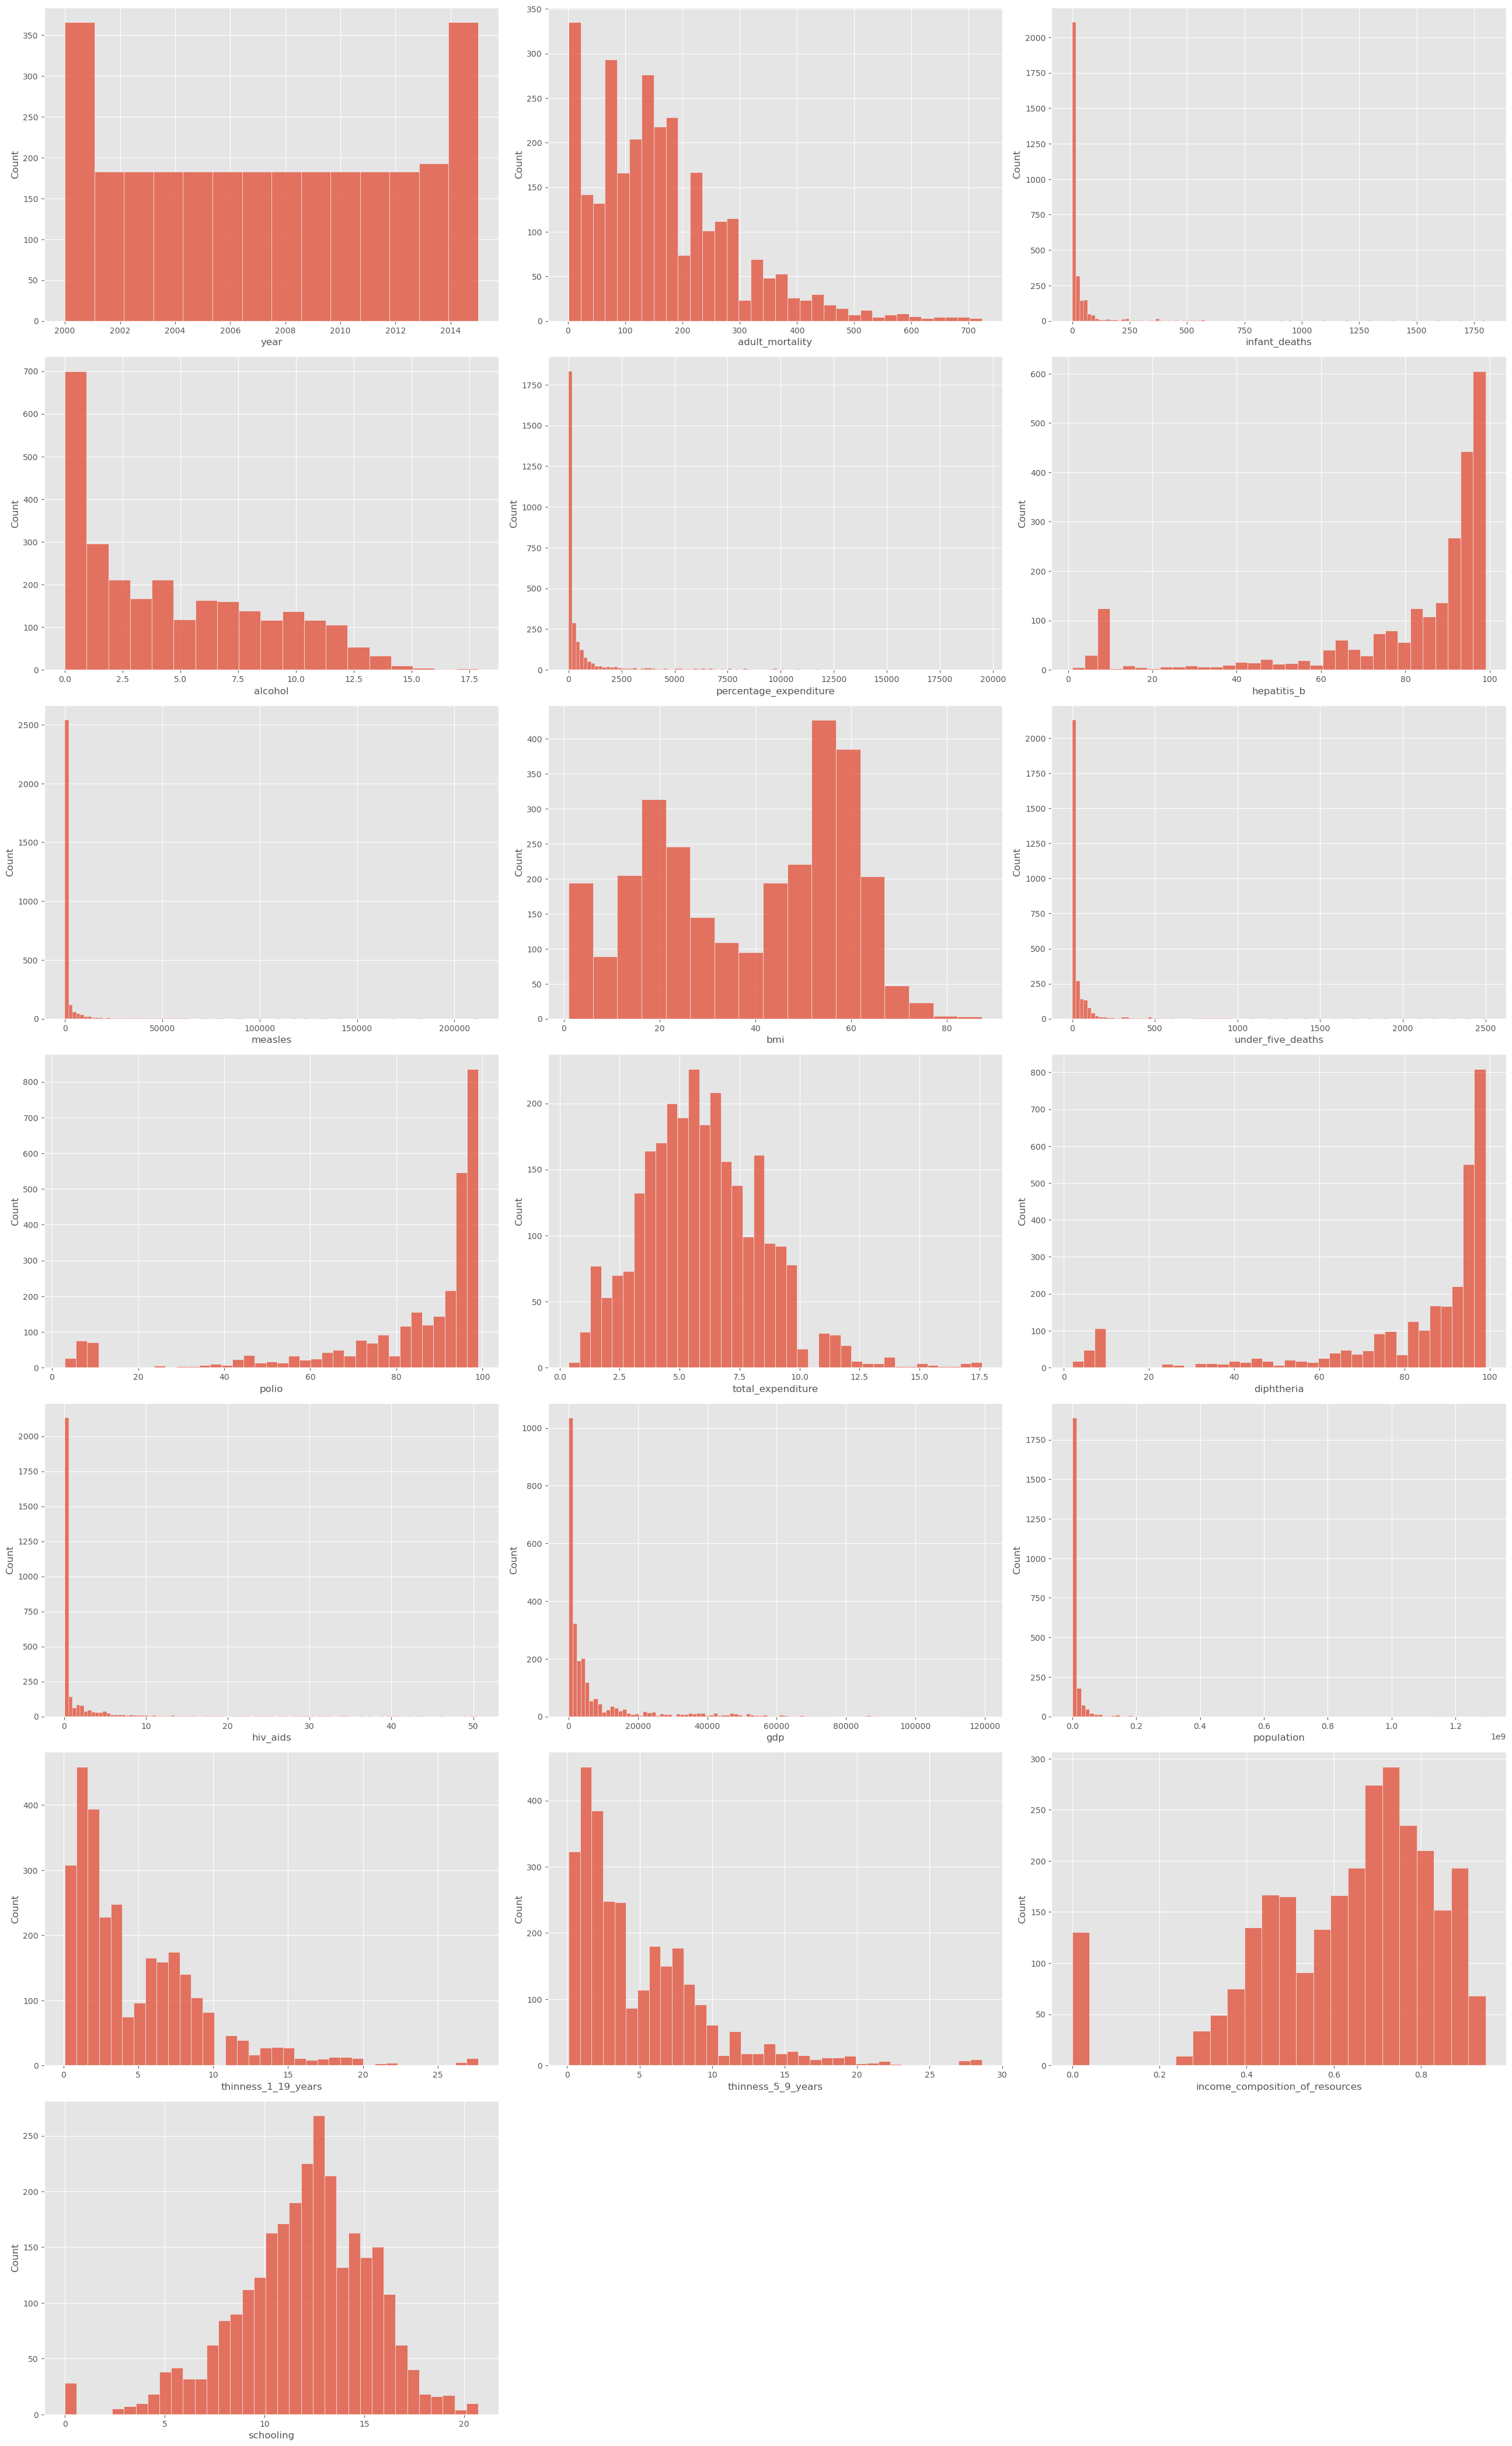

In [133]:

import math


cols = 3
rows = math.ceil(len(numerical_features) / cols)

fig , axes = plt.subplots(rows, cols, figsize= (26, 6 * rows))

axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(data = df, x=feature, ax = axes[i])
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

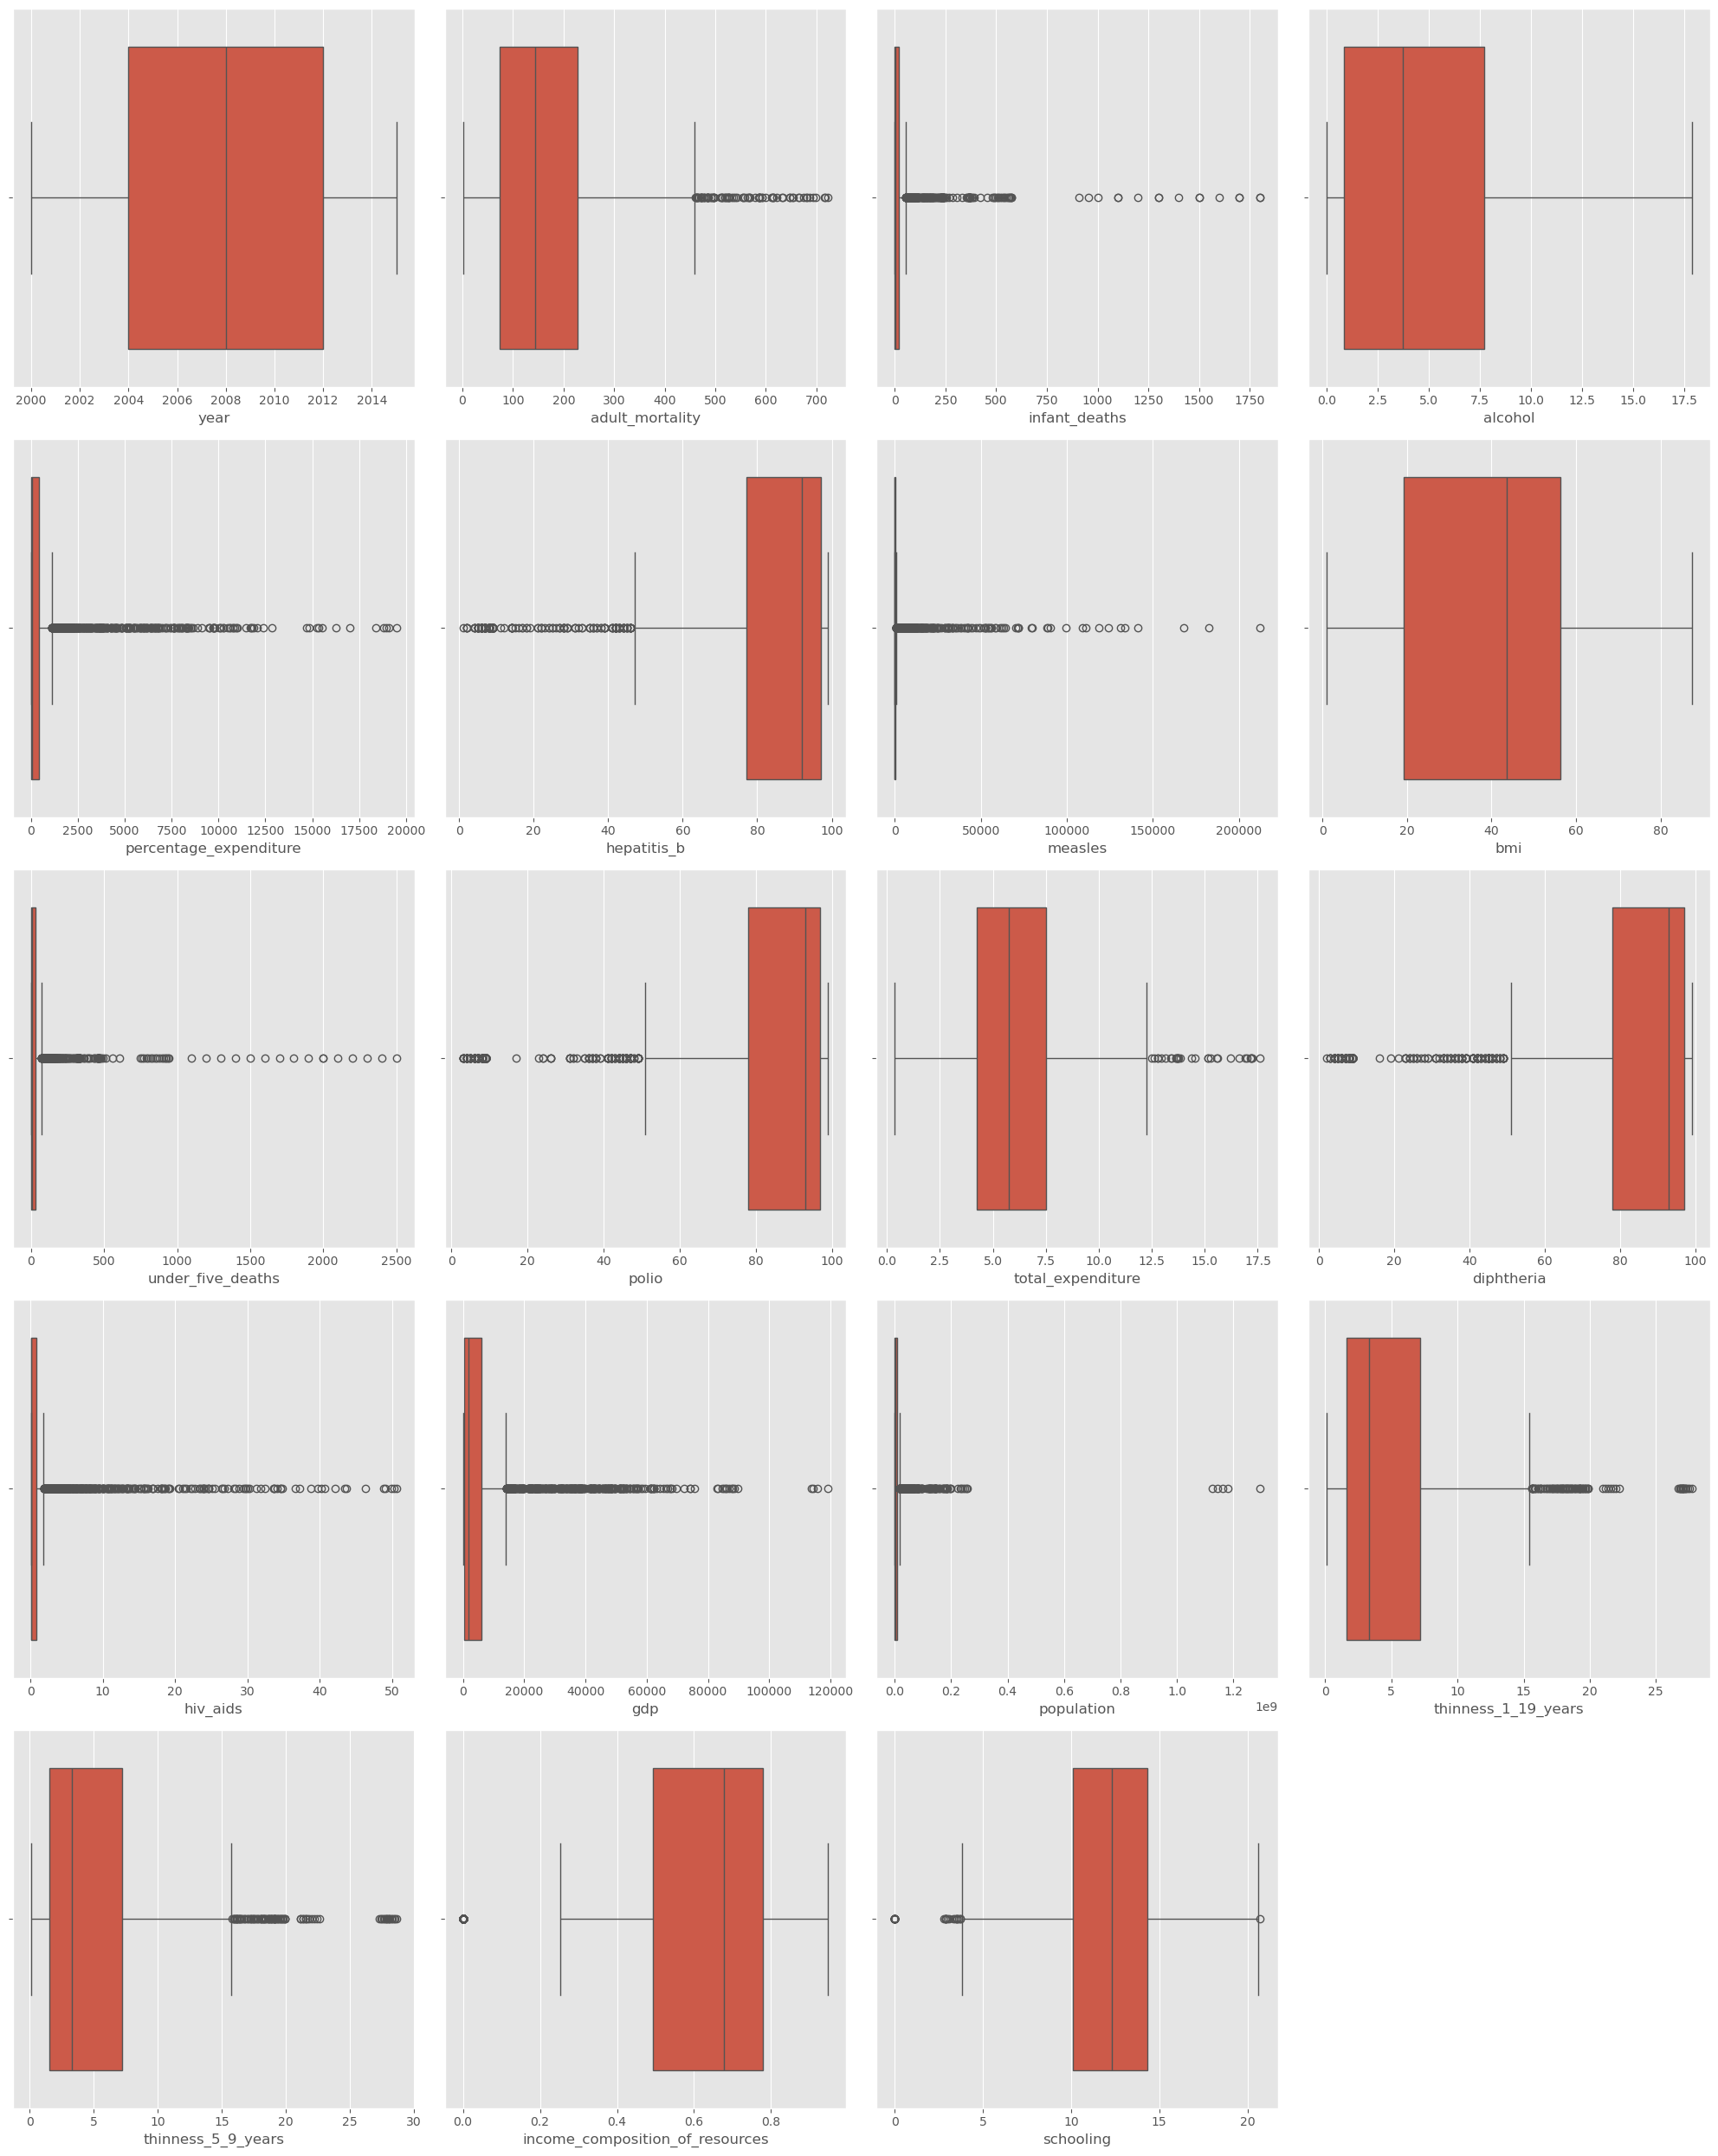

In [120]:
fig , axes = plt.subplots(rows, cols, figsize= (20, 5 * rows))

axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(data = df, x=feature, ax = axes[i])
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

## EDA Notes: Boxplots of Numerical Features

The boxplots show that many numerical features contain substantial skewness and a large number of outliers, especially on the upper end. This is particularly evident for `gdp`, `population`, `measles`, `infant_deaths`, `under_five_deaths`, `percentage_expenditure`, and `hiv_aids`, where most observations are concentrated near smaller values while a limited number of observations extend to very large values.

Some features appear more stable and less extreme in comparison, including `year`, `alcohol`, `bmi`, `total_expenditure`, `income_composition_of_resources`, and `schooling`. These variables still vary in spread but show fewer severe outliers.

Vaccination-related features such as `hepatitis_b`, `polio`, and `diphtheria` are concentrated near higher values, with lower-end outliers that may reflect countries or years with weaker immunization coverage. Similarly, `thinness_1_19_years` and `thinness_5_9_years` show right-skewed distributions with some notable upper outliers.

Overall, the boxplots suggest that several numerical variables are heavily skewed and may benefit from transformation or careful handling during preprocessing. However, most observed outliers appear logically plausible rather than obvious data errors, so they should be documented and examined rather than removed automatically.

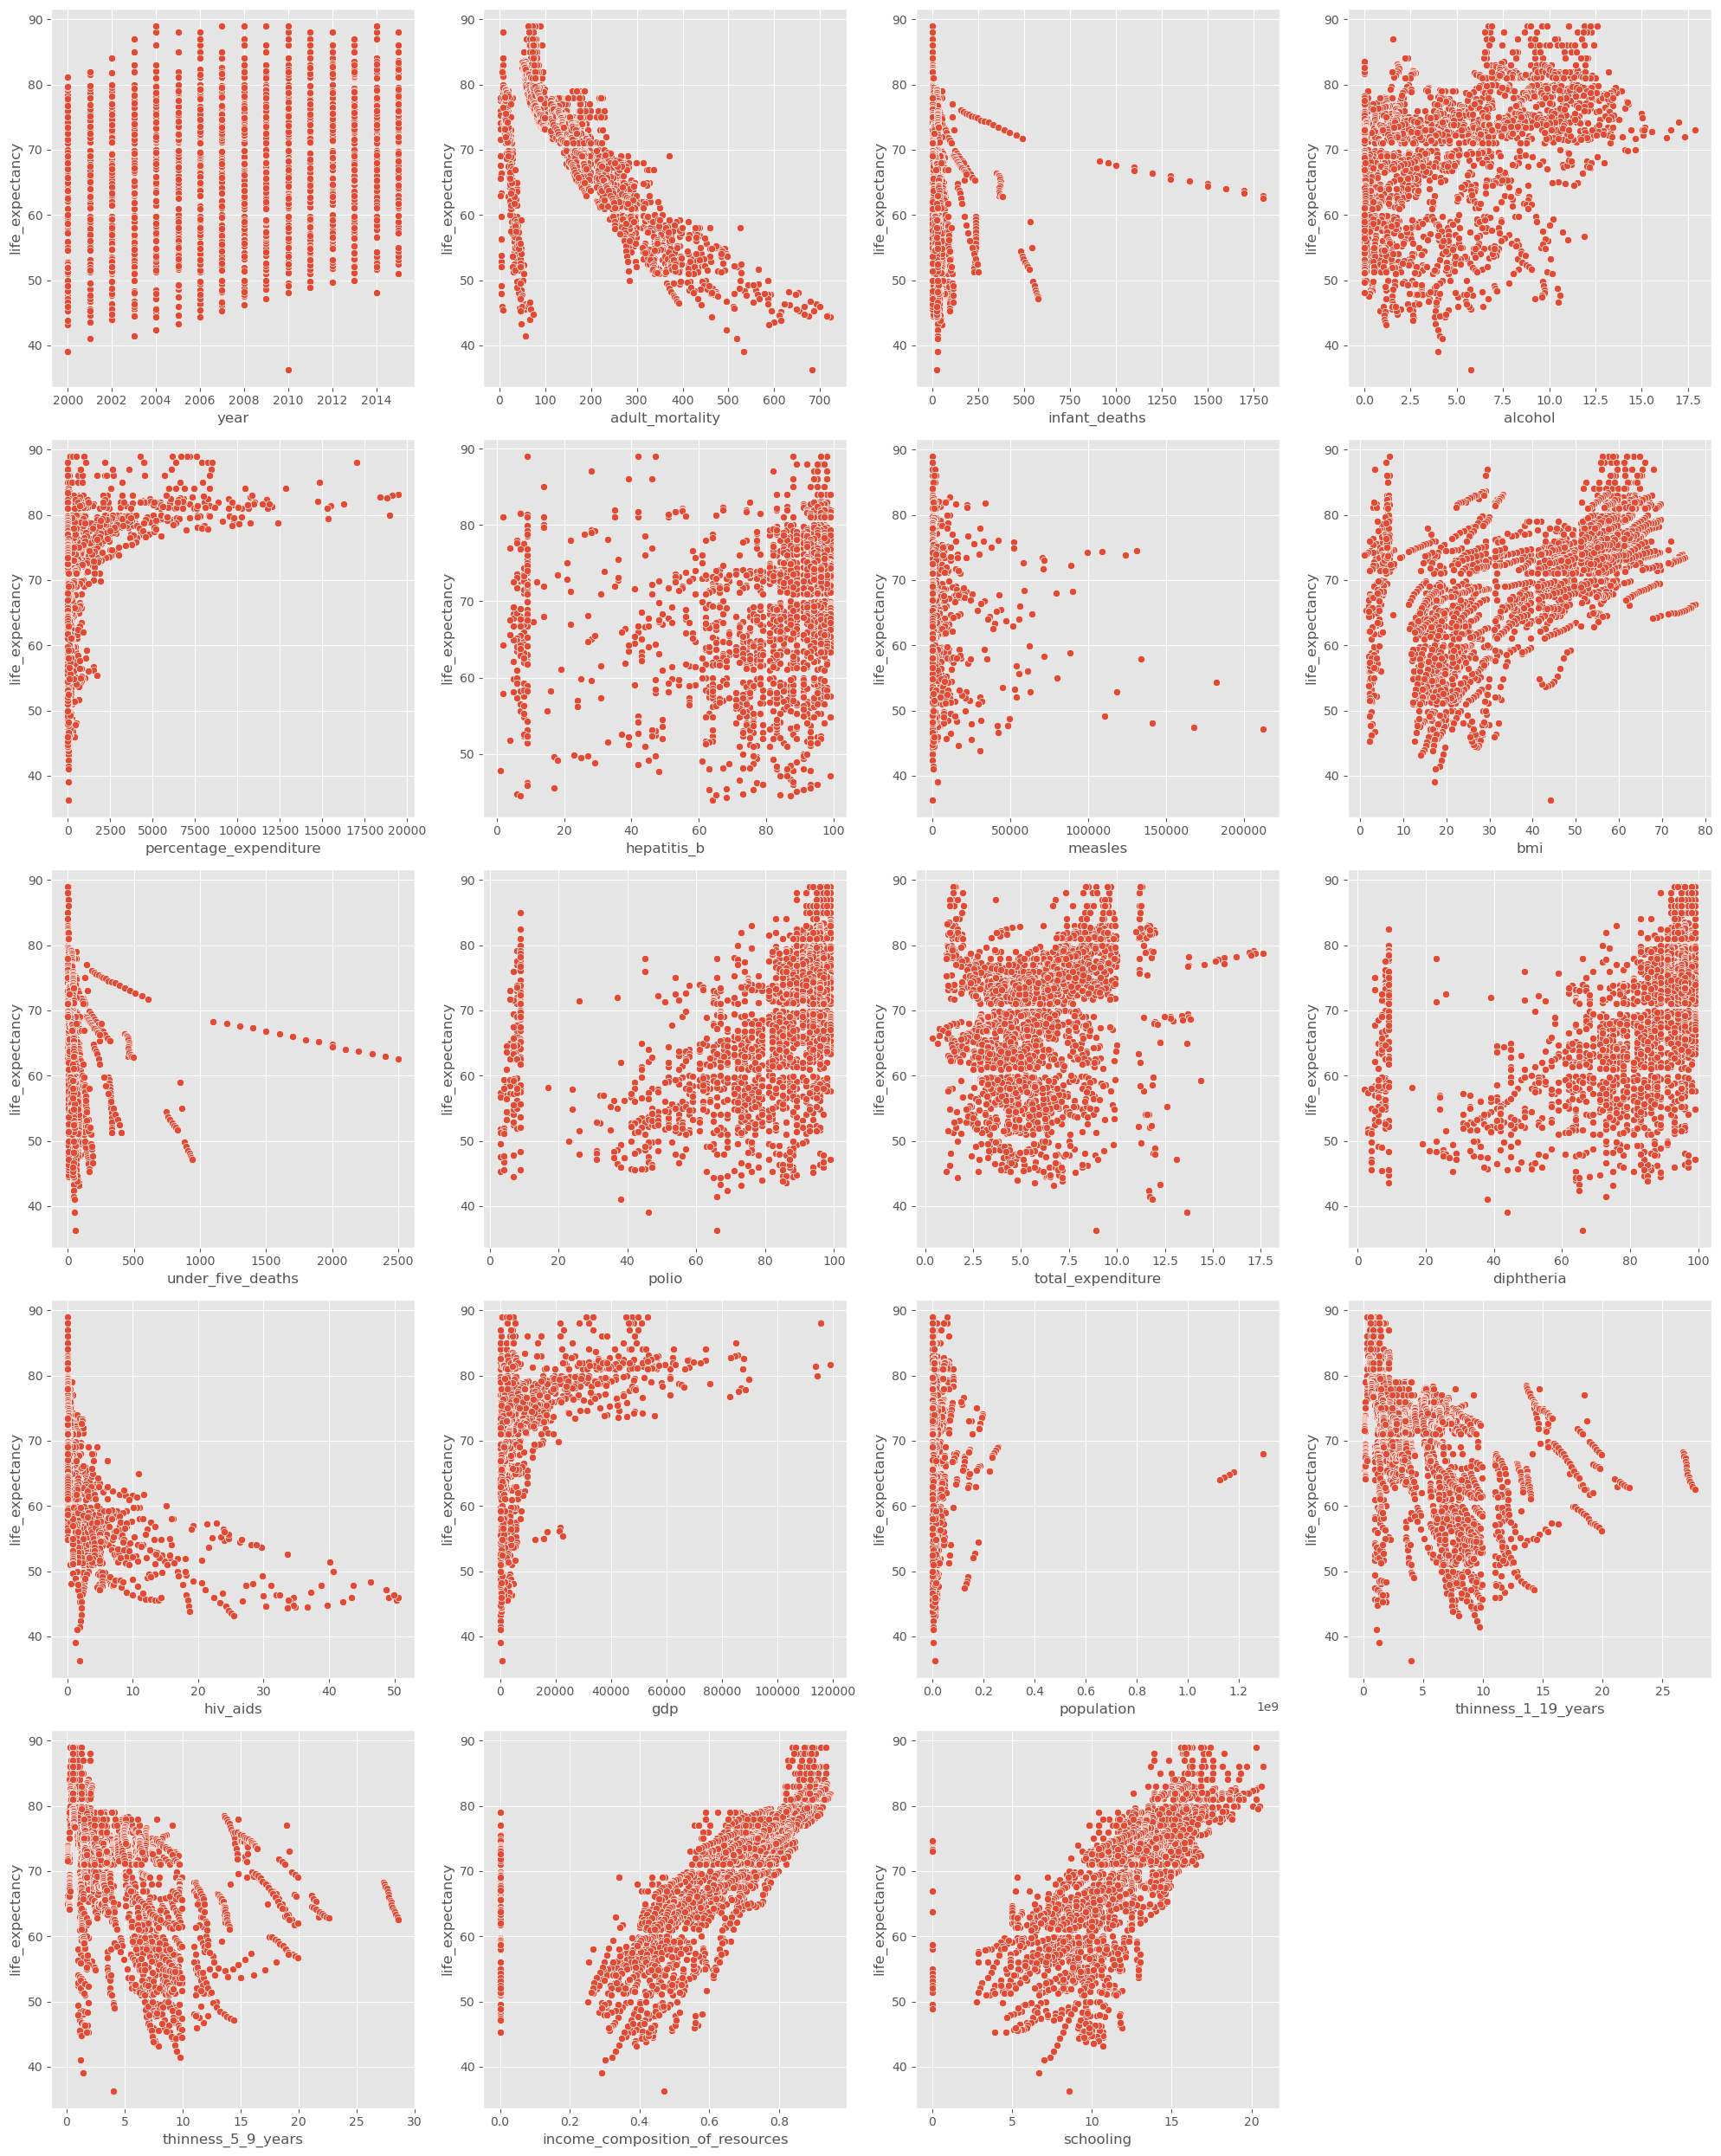

In [121]:



fig , axes = plt.subplots(rows, cols, figsize= (20, 5 * rows))

axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.scatterplot(data = df, x=feature, y=target, ax = axes[i])
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

In [122]:
df[numerical_features].skew().sort_values(ascending=False)

population                         15.916236
infant_deaths                       9.786963
under_five_deaths                   9.495065
measles                             9.441332
hiv_aids                            5.396112
percentage_expenditure              4.652051
gdp                                 3.206655
thinness_5_9_years                  1.777424
thinness_1_19_years                 1.711471
adult_mortality                     1.174369
total_expenditure                   0.618686
alcohol                             0.589563
year                               -0.006409
bmi                                -0.219312
schooling                          -0.602437
income_composition_of_resources    -1.143763
hepatitis_b                        -1.930845
diphtheria                         -2.072753
polio                              -2.098053
dtype: float64

In [123]:
df.corr(numeric_only=True)[target].sort_values(ascending=False)


life_expectancy                    1.000000
schooling                          0.751975
income_composition_of_resources    0.724776
bmi                                0.567694
diphtheria                         0.479495
polio                              0.465556
gdp                                0.461455
alcohol                            0.404877
percentage_expenditure             0.381864
hepatitis_b                        0.256762
total_expenditure                  0.218086
year                               0.170033
population                        -0.021538
measles                           -0.157586
infant_deaths                     -0.196557
under_five_deaths                 -0.222529
thinness_5_9_years                -0.471584
thinness_1_19_years               -0.477183
hiv_aids                          -0.556556
adult_mortality                   -0.696359
Name: life_expectancy, dtype: float64

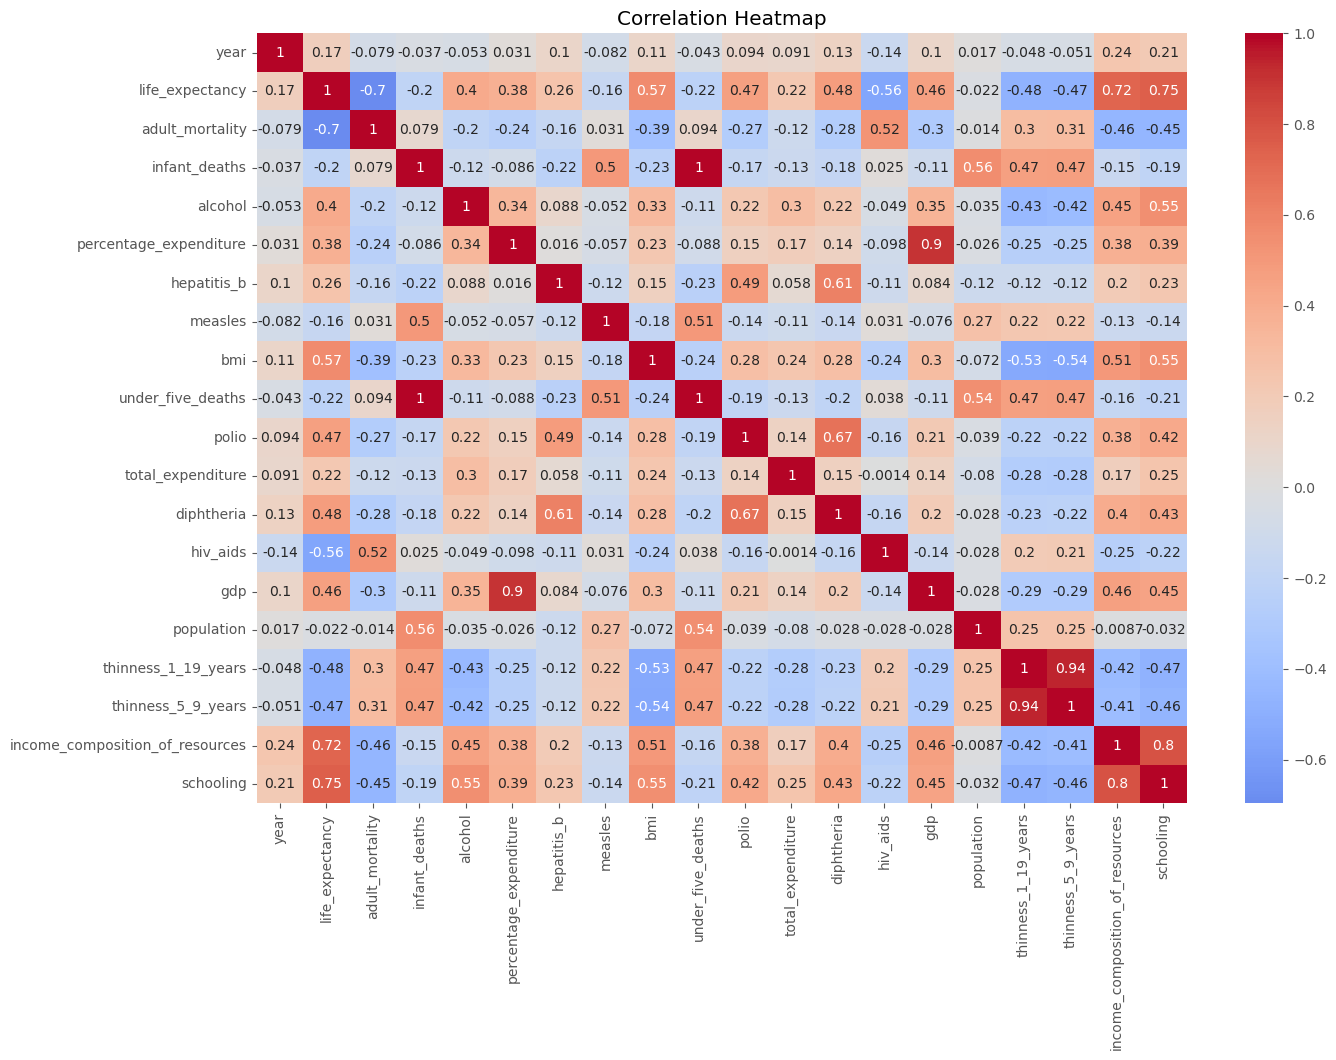

In [124]:
s = df.corr(numeric_only=True)
plt.figure(figsize=(15, 10))
sns.heatmap(s, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## EDA Notes: Correlation Heatmap

The correlation heatmap shows several strong linear relationships with `life_expectancy`.

### Features most positively correlated with life expectancy
The strongest positive correlations are:
- `schooling` (0.75)
- `income_composition_of_resources` (0.72)
- `bmi` (0.57)
- `diphtheria` (0.48)
- `polio` (0.47)
- `gdp` (0.46)
- `alcohol` (0.40)
- `percentage_expenditure` (0.38)

These suggest that higher education, stronger resource composition, better nutrition, vaccination coverage, and economic development are associated with higher life expectancy.

### Features most negatively correlated with life expectancy
The strongest negative correlations are:
- `adult_mortality` (-0.70)
- `hiv_aids` (-0.56)
- `thinness_1_19_years` (-0.48)
- `thinness_5_9_years` (-0.47)

These indicate that mortality burden, HIV/AIDS prevalence, and thinness-related indicators are associated with lower life expectancy.

### Multicollinearity / redundancy
The heatmap also reveals several highly correlated predictor pairs:
- `infant_deaths` and `under_five_deaths` (1.00)
- `thinness_1_19_years` and `thinness_5_9_years` (0.94)
- `percentage_expenditure` and `gdp` (0.90)
- `income_composition_of_resources` and `schooling` (0.80)
- `polio` and `diphtheria` (0.67)

These pairs likely contain overlapping information and may introduce multicollinearity in linear models. This will be important to consider during preprocessing and feature selection.

### Overall conclusion
The correlation structure suggests that life expectancy is strongly linked to education, socioeconomic development, vaccination coverage, nutrition, and mortality-related health indicators. At the same time, some predictors appear highly redundant, meaning later feature selection or multicollinearity handling may be necessary.

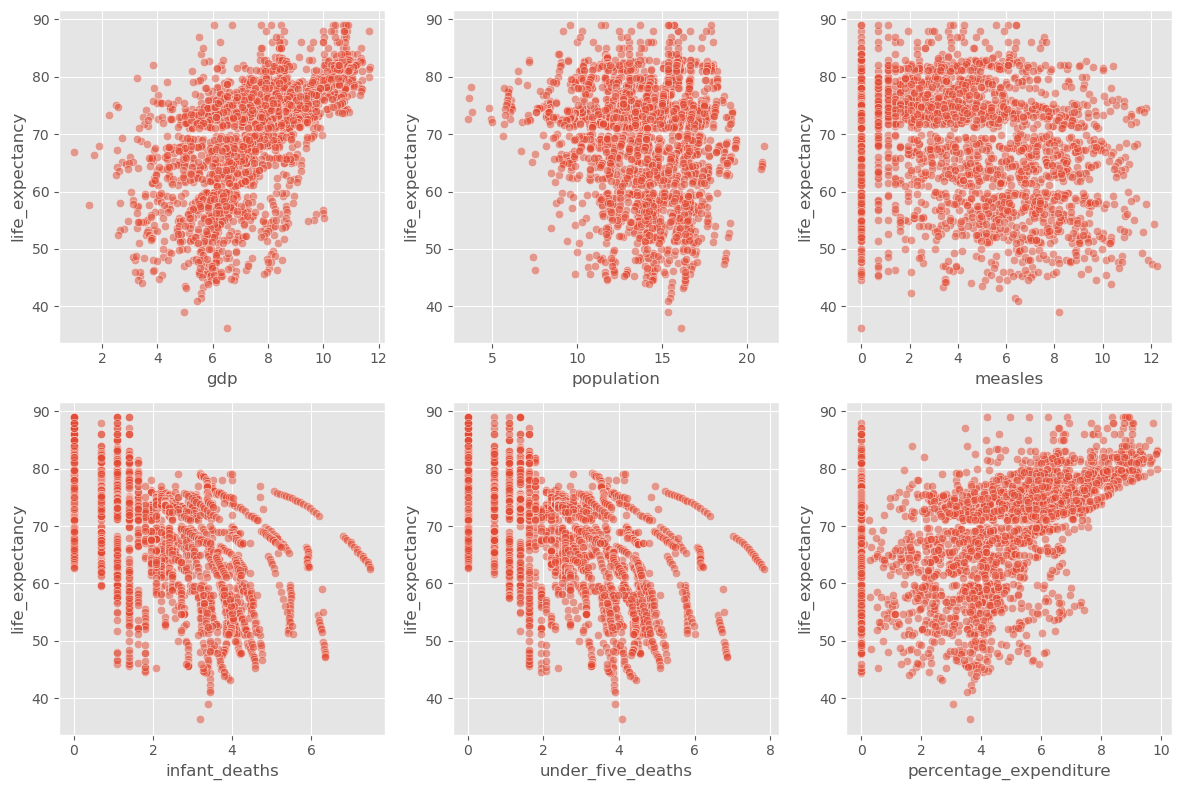

In [125]:
import numpy as np
import matplotlib.pyplot as plt

cols_to_log_view = [
    "gdp",
    "population",
    "measles",
    "infant_deaths",
    "under_five_deaths",
    "percentage_expenditure"
]

# for col in cols_to_log_view:
#     plt.figure(figsize=(6, 4))
#     plt.scatter(np.log1p(df[col]), df["life_expectancy"], alpha=0.5)
#     plt.xlabel(f"log1p({col})")
#     plt.ylabel("life_expectancy")
#     plt.title(f"Life Expectancy vs log1p({col})")
#     plt.show()



cols = 3
rows = math.ceil(len(cols_to_log_view) / cols)

fig , axes = plt.subplots(rows, cols, figsize= (12, 4 * rows))

axes = axes.flatten()

for i, feature in enumerate(cols_to_log_view):
    sns.scatterplot(data = df, x=np.log1p(df[feature]), y="life_expectancy", ax = axes[i], alpha=0.5, )
    
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

In [126]:
(df['infant_deaths'] == df['under_five_deaths']).all()

np.False_

In [127]:
(df['infant_deaths'] - df['under_five_deaths']).describe()

count    2938.00000
mean      -11.73179
std        43.99361
min      -700.00000
25%        -6.00000
50%        -1.00000
75%         0.00000
max         0.00000
dtype: float64

In [128]:
df[["infant_deaths", "under_five_deaths"]].isnull().sum()

infant_deaths        0
under_five_deaths    0
dtype: int64

In [129]:
df[["infant_deaths", "under_five_deaths"]].corr()

,infant_deaths,under_five_deaths
infant_deaths,1.000000,0.996629
under_five_deaths,0.996629,1.000000


In [130]:
df[["infant_deaths", "under_five_deaths", "life_expectancy"]].corr()

,infant_deaths,under_five_deaths,life_expectancy
infant_deaths,1.000000,0.996629,-0.196557
under_five_deaths,0.996629,1.000000,-0.222529
life_expectancy,-0.196557,-0.222529,1.000000


## EDA Notes: Numerical Scatterplots and Log-Scaled Views

### 1. Takeaways from the original scatterplots
The scatterplots between numerical features and `life_expectancy` showed several useful patterns:

- **Strong positive relationships** were visible for:
  - `schooling`
  - `income_composition_of_resources`
  - `bmi`
  - `polio`
  - `diphtheria`

- **Strong negative relationships** were visible for:
  - `adult_mortality`
  - `hiv_aids`
  - `infant_deaths`
  - `under_five_deaths`
  - `thinness_1_19_years`

- Some features appeared **weak, noisy, or difficult to interpret directly** from the raw scatterplots:
  - `population`
  - `measles`
  - `hepatitis_b`
  - `total_expenditure`
  - `alcohol`
  - `percentage_expenditure`

- Several numerical columns were clearly **heavily right-skewed**, causing most observations to be compressed near small values while a few extreme values dominated the scale. This made some raw scatterplots hard to interpret.

### 2. Takeaways from log-transformed scatterplots
Log scaling improved the interpretability of highly skewed features. In particular:

- `gdp` showed a much clearer **positive relationship** with `life_expectancy` after log transformation.
- `infant_deaths` showed a clearer **negative relationship** with `life_expectancy`.
- `under_five_deaths` showed a clearer **negative relationship** with `life_expectancy`.
- `percentage_expenditure` showed a more visible **positive relationship** after transformation.

However, not every feature became strongly informative after log scaling:

- `population` remained relatively weak and noisy.
- `measles` still appeared scattered and did not show a strong simple relationship with the target.

### 3. Infant deaths vs under-five deaths
Further inspection showed that:

- `infant_deaths` and `under_five_deaths` are **not identical columns**.
- However, they are **extremely highly correlated**, meaning they contain very similar information.
- This is logically reasonable because under-five deaths include infant deaths and deaths from ages 1 to 4.
- `under_five_deaths` has a slightly **stronger negative correlation** with `life_expectancy` than `infant_deaths`.

### 4. Overall conclusion
The scatterplots suggest that the dataset contains several numerically meaningful predictors of `life_expectancy`, especially features related to mortality, health, education, and socioeconomic development. Log transformation was particularly helpful for understanding skewed variables such as `gdp`, `infant_deaths`, `under_five_deaths`, and `percentage_expenditure`.

The analysis also identified redundancy between `infant_deaths` and `under_five_deaths`, which is an important finding for later preprocessing and model building, especially when using linear models where multicollinearity can affect interpretability.

In [135]:
categorical_cols = df.select_dtypes(include=['str']).columns.tolist()
categorical_cols

['country', 'status']

In [136]:
df['status'].value_counts(dropna=False)
df['status'].isnull().sum()

np.int64(0)

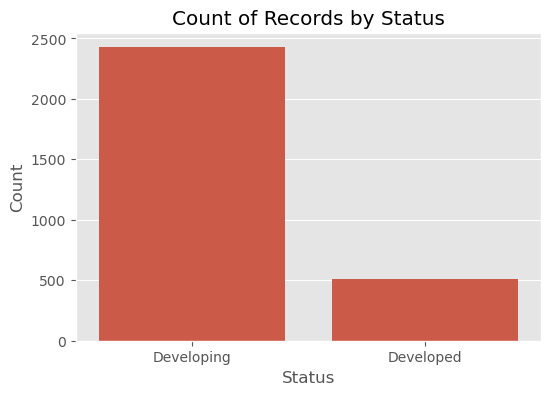

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="status")
plt.title("Count of Records by Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

In [139]:
df.groupby('status')['life_expectancy'].describe()


,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
Developed,512.0,79.197852,3.930942,69.9,76.8,79.25,81.7,89.0
Developing,2416.0,67.111465,9.006092,36.3,61.1,69.00,74.0,89.0


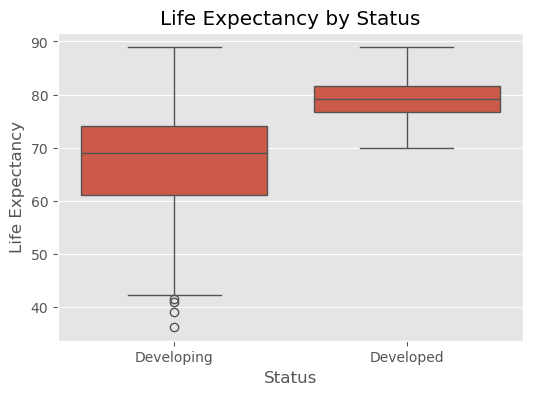

In [140]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="status", y="life_expectancy")
plt.title("Life Expectancy by Status")
plt.xlabel("Status")
plt.ylabel("Life Expectancy")
plt.show()

In [141]:
df.groupby("status")[["schooling", "adult_mortality", "gdp", "hiv_aids"]].mean()

,schooling,adult_mortality,gdp,hiv_aids
status,,,,
Developed,15.845474,79.685547,22053.386446,0.100000
Developing,11.219256,182.833195,4286.556053,2.088664


In [143]:
groupby_country = df.groupby("country")[["schooling", "adult_mortality", "gdp", "hiv_aids", "life_expectancy"]].mean()
groupby_country.head(10)

,schooling,adult_mortality,gdp,hiv_aids,life_expectancy
country,,,,,
Afghanistan,8.21250,269.0625,340.015425,0.10000,58.19375
Albania,12.13750,45.0625,2119.726679,0.10000,75.15625
Algeria,12.71250,108.1875,2847.853392,0.10000,73.61875
Angola,8.04375,328.5625,1975.143045,2.36875,49.01875
Antigua and Barbuda,8.84375,127.5000,9759.305728,0.12500,75.05625
Argentina,16.50625,106.0000,6998.575103,0.10000,75.15625
Armenia,11.78750,117.3750,1999.986318,0.10000,73.40000
Australia,20.03750,63.1875,34637.565047,0.10000,81.81250
Austria,15.38750,65.7500,33827.476309,0.10000,81.48125


In [144]:
groupby_country.tail(10)

,schooling,adult_mortality,gdp,hiv_aids,life_expectancy
country,,,,,
United Republic of Tanzania,NaN,304.4375,NaN,7.27500,56.00625
United States of America,NaN,58.1875,NaN,0.10000,78.06250
Uruguay,15.23125,119.9375,7192.584875,0.10000,76.07500
Uzbekistan,11.64375,184.8125,651.092359,0.20625,68.03125
Vanuatu,10.56875,137.8750,2000.245518,0.10000,71.38750
Venezuela (Bolivarian Republic of),12.78750,163.0000,NaN,0.10000,73.38750
Viet Nam,11.51250,126.5625,NaN,0.14375,74.77500
Yemen,8.50625,211.8125,NaN,0.10000,63.86250
Zambia,11.21250,354.3125,811.811841,11.93125,53.90625


In [165]:
usa_by_year = (
    df.loc[df["country"].isin(["United States of America"])]
    .sort_values("year")
    .set_index("year")
    .select_dtypes(include = ["number"])
)

usa_by_year.head(10)

,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under_five_deaths,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness_1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
year,,,,,,,,,,,,,,,,,,,
2000,76.8,114.0,28,8.21,0.0,9.0,85,6.1,33,9.0,13.70,94.0,0.1,NaN,NaN,0.8,0.7,NaN,NaN
2001,76.9,115.0,28,8.25,0.0,89.0,116,6.9,33,89.0,13.73,94.0,0.1,NaN,NaN,0.8,0.6,NaN,NaN
2002,77.0,115.0,28,8.33,0.0,88.0,41,61.7,33,9.0,14.55,94.0,0.1,NaN,NaN,0.8,0.6,NaN,NaN
2003,77.2,114.0,28,8.40,0.0,92.0,56,62.4,33,91.0,15.60,96.0,0.1,NaN,NaN,0.7,0.6,NaN,NaN
2004,77.5,111.0,28,8.48,0.0,92.0,37,63.1,33,92.0,15.14,96.0,0.1,NaN,NaN,0.7,0.6,NaN,NaN
2005,77.5,112.0,28,8.52,0.0,93.0,66,63.8,33,92.0,15.15,96.0,0.1,NaN,NaN,0.7,0.6,NaN,NaN
2006,77.8,113.0,28,8.63,0.0,93.0,55,64.4,33,93.0,15.27,96.0,0.1,NaN,NaN,0.7,0.6,NaN,NaN
2007,78.1,11.0,27,8.74,0.0,93.0,43,65.1,32,93.0,15.57,96.0,0.1,NaN,NaN,0.7,0.6,NaN,NaN
2008,78.2,18.0,27,8.74,0.0,94.0,140,65.7,31,94.0,16.20,96.0,0.1,NaN,NaN,0.7,0.6,NaN,NaN


In [158]:
usa_by_year.tail(10)

,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under_five_deaths,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness_1_19_years,thinness_5_9_years,income_composition_of_resources,schooling
year,,,,,,,,,,,,,,,,,,,
2006,77.8,113.0,28,8.63,0.0,93.0,55,64.4,33,93.0,15.27,96.0,0.1,NaN,NaN,0.7,0.6,NaN,NaN
2007,78.1,11.0,27,8.74,0.0,93.0,43,65.1,32,93.0,15.57,96.0,0.1,NaN,NaN,0.7,0.6,NaN,NaN
2008,78.2,18.0,27,8.74,0.0,94.0,140,65.7,31,94.0,16.20,96.0,0.1,NaN,NaN,0.7,0.6,NaN,NaN
2009,78.5,18.0,26,8.71,0.0,92.0,71,66.3,31,93.0,17.00,95.0,0.1,NaN,NaN,0.7,0.6,NaN,NaN
2010,78.7,15.0,25,8.55,0.0,92.0,63,66.9,30,93.0,17.20,95.0,0.1,NaN,NaN,0.7,0.6,NaN,NaN
2011,78.7,16.0,25,8.67,0.0,91.0,220,67.5,29,94.0,17.60,96.0,0.1,NaN,NaN,0.7,0.6,NaN,NaN
2012,78.8,16.0,24,8.82,0.0,9.0,55,68.0,28,93.0,17.20,94.0,0.1,NaN,NaN,0.7,0.6,NaN,NaN
2013,78.9,16.0,23,8.82,0.0,91.0,187,68.6,27,93.0,16.90,94.0,0.1,NaN,NaN,0.7,0.6,NaN,NaN
2014,79.1,14.0,23,8.82,0.0,92.0,667,69.1,27,93.0,17.14,95.0,0.1,NaN,NaN,0.8,0.6,NaN,NaN


### Takeaway from inspection of USA data 
Interpolation is not possible for some rows of the dataset, Such as the case of United States of America, which has missing values for 'gdp' and 'income_composition_of_resources', 'schooling' features, which are some of the most important features in the dataset. Therefore, we will not be able to use interpolation to fill in the missing values for these features for the United States of America.

In [168]:
yearly_life = df.groupby("year")["life_expectancy"].mean()
yearly_life.head(10)

year
2000    66.750273
2001    67.128962
2002    67.351366
2003    67.433333
2004    67.646448
2005    68.209290
2006    68.667760
2007    69.036066
2008    69.427869
2009    69.938251
Name: life_expectancy, dtype: float64

<Axes: title={'center': 'Average Life Expectancy Over the Years'}, xlabel='year'>

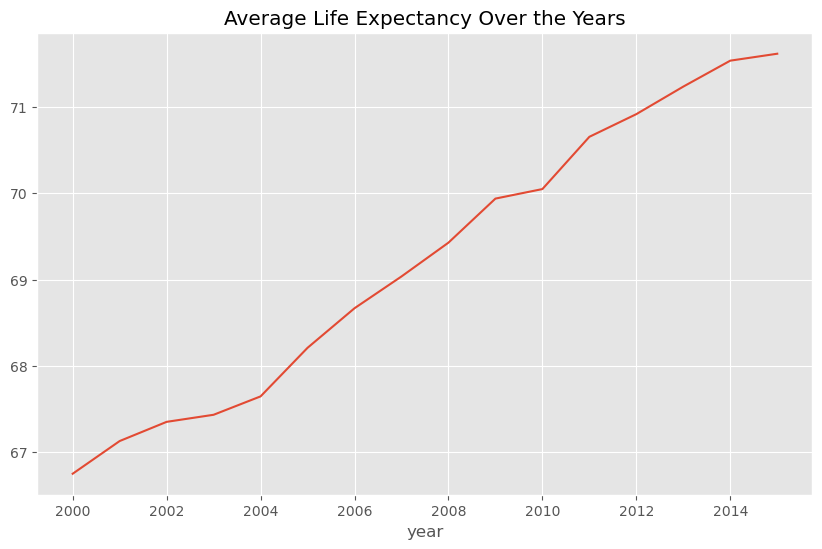

In [169]:
yearly_life.plot(figsize=(10, 6), title="Average Life Expectancy Over the Years")

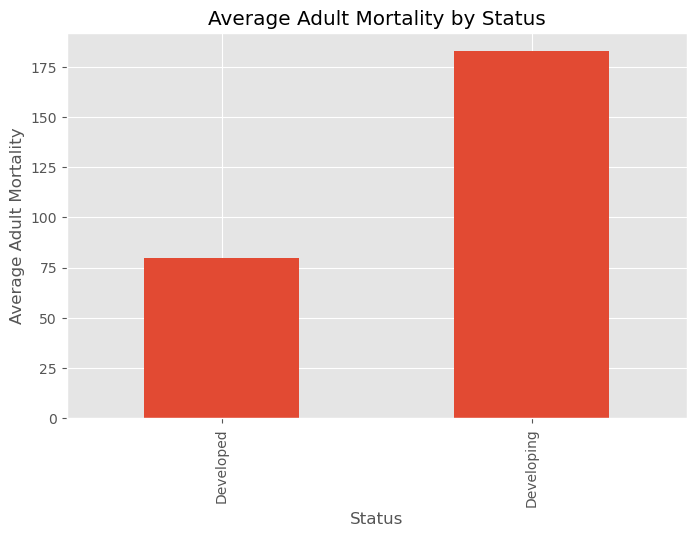

In [170]:
adult_mortality_by_status = df.groupby("status")["adult_mortality"].mean()
adult_mortality_by_status.plot(kind="bar", figsize=(8, 5), title="Average Adult Mortality by Status")
plt.xlabel("Status")
plt.ylabel("Average Adult Mortality")
plt.show()

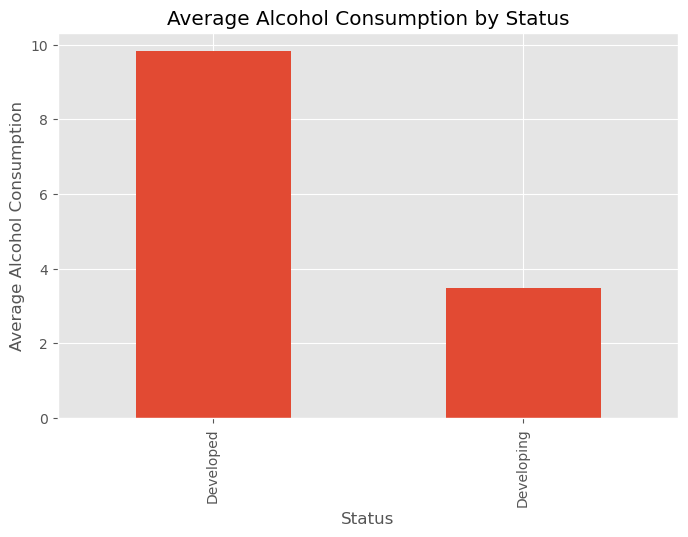

In [171]:
alcohol_consumption_by_status = df.groupby("status")["alcohol"].mean()
alcohol_consumption_by_status.plot(kind="bar", figsize=(8, 5), title="Average Alcohol Consumption by Status")
plt.xlabel("Status")
plt.ylabel("Average Alcohol Consumption")
plt.show()

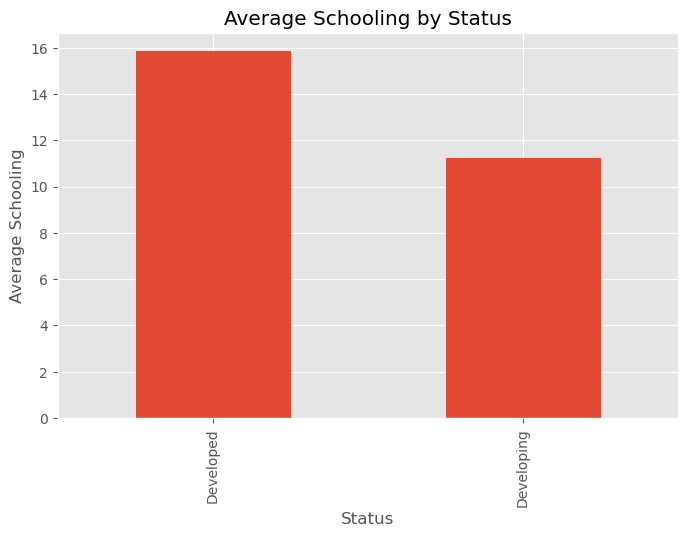

In [172]:
schooling_by_status = df.groupby("status")["schooling"].mean()
schooling_by_status.plot(kind="bar", figsize=(8, 5), title="Average Schooling by Status")
plt.xlabel("Status")
plt.ylabel("Average Schooling")
plt.show()

In [173]:
life_expectancy_by_country = df.groupby("country")["life_expectancy"].mean().sort_values(ascending=False)
life_expectancy_by_country.head(10)

country
Japan          82.53750
Sweden         82.51875
Iceland        82.44375
Switzerland    82.33125
France         82.21875
Italy          82.18750
Spain          82.06875
Australia      81.81250
Norway         81.79375
Canada         81.68750
Name: life_expectancy, dtype: float64

In [174]:
life_expectancy_by_country.tail(10)

country
Cook Islands            NaN
Dominica                NaN
Marshall Islands        NaN
Monaco                  NaN
Nauru                   NaN
Niue                    NaN
Palau                   NaN
Saint Kitts and Nevis   NaN
San Marino              NaN
Tuvalu                  NaN
Name: life_expectancy, dtype: float64



## Exploratory Data Analysis Summary

This project uses the **Life Expectancy** dataset containing **2938 rows** and **22 columns**. The target variable is `life_expectancy`, and the dataset includes health, mortality, immunization, economic, education, and demographic indicators across countries and years.

### Main findings
- The target variable `life_expectancy` has a **moderate negative skew** (`-0.6386`) and contains a small number of missing values.
- Several features show strong relationships with life expectancy:
  - **Positive:** `schooling`, `income_composition_of_resources`, `bmi`, `polio`, `diphtheria`, `gdp`
  - **Negative:** `adult_mortality`, `hiv_aids`, `thinness_1_19_years`, `thinness_5_9_years`
- Many numerical features are **heavily right-skewed** and contain plausible outliers, especially:
  - `gdp`
  - `population`
  - `measles`
  - `infant_deaths`
  - `under_five_deaths`
  - `percentage_expenditure`
- Log-scaled visualizations made some relationships much clearer, especially for:
  - `gdp`
  - `infant_deaths`
  - `under_five_deaths`
  - `percentage_expenditure`

### Correlation insights
The strongest positive correlations with `life_expectancy` were:
- `schooling` (`0.75`)
- `income_composition_of_resources` (`0.72`)
- `bmi` (`0.57`)

The strongest negative correlations were:
- `adult_mortality` (`-0.70`)
- `hiv_aids` (`-0.56`)

### Multicollinearity / redundancy
Several feature pairs appear highly redundant:
- `infant_deaths` and `under_five_deaths`
- `thinness_1_19_years` and `thinness_5_9_years`
- `percentage_expenditure` and `gdp`
- `income_composition_of_resources` and `schooling`

This will matter later when training linear models.

### Categorical findings
The `status` feature is highly informative:
- **Developed** countries have much higher average life expectancy than **Developing** countries.
- Developed countries also tend to have:
  - higher schooling
  - higher GDP
  - lower adult mortality
  - lower HIV/AIDS burden

### Overall conclusion
The dataset contains meaningful predictive signal for a regression task, but careful preprocessing will be needed before modeling. Key preprocessing concerns include:
- missing values
- skewed distributions
- plausible outliers
- highly correlated predictors
- possible feature transformations